# Capstone Project — Template Notebook

**FDP: Machine Learning for Materials and Metallurgical Engineering | 13–18 July 2026**

This notebook is a **fully worked example** showing every step of a capstone project, start to finish, using Random Forest regression on the steel strength dataset (the same one from Day 3, Session 2).

**How to use this template:** copy this notebook, then replace the dataset, problem statement, and interpretation in each section with your own group's project — keep the same overall structure. Sections marked 🔧 are where you'll make the most changes; sections marked 📌 are usually reusable with only small edits.


## 1. Problem Statement 🔧

**Example (this notebook):** Can we predict a steel's **tensile strength** from its **alloying element composition**? If so, which elements matter most? This matters because it lets a metallurgist estimate strength before running a physical tensile test — useful for early-stage alloy design.

**Your group:** replace this with your own question. A good problem statement is one sentence, names the target you're predicting (or the structure you're uncovering, if clustering), and says in plain terms why it matters for materials/metallurgical practice.


## 2. Imports 📌

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
np.random.seed(42)


## 3. Dataset 🔧

**Source:** Kateb & Safarian (2025) steel strength dataset — 312 steels, 13 alloying-element fractions (C, Mn, Si, Cr, Ni, Mo, V, N, Nb, Co, W, Al, Ti) with measured yield strength, tensile strength, and elongation. Same file used in Day 3, Session 2 (`steel_strength.csv`).

**Your group:** load your own dataset here instead. State its source, size, and what each column means.


In [2]:
df = pd.read_csv("steel_strength.csv")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Shape: 312 rows, 17 columns


,formula,c,mn,si,cr,ni,mo,v,n,nb,co,w,al,ti,yield strength,tensile strength,elongation
0,Fe0.620C0.000953Mn0.000521Si0.00102Cr0.000110N...,0.02,0.05,0.05,0.01,19.70,2.95,0.01,0.00,0.01,15.00,0.00,0.15,1.55,2411.5,2473.5,7.0
1,Fe0.623C0.00854Mn0.000104Si0.000203Cr0.147Ni0....,0.18,0.01,0.01,13.44,0.01,3.01,0.46,0.04,0.01,19.46,2.35,0.04,0.00,1123.1,1929.2,8.0
2,Fe0.625Mn0.000102Si0.000200Cr0.0936Ni0.129Mo0....,0.00,0.01,0.01,8.67,13.45,0.82,0.01,0.00,0.01,13.90,0.00,0.39,0.57,1736.3,1871.8,NaN
3,Fe0.634C0.000478Mn0.000523Si0.00102Cr0.000111N...,0.01,0.05,0.05,0.01,17.70,3.95,0.01,0.00,0.01,15.00,0.00,0.13,1.47,2487.3,2514.9,9.0
4,Fe0.636C0.000474Mn0.000518Si0.00101Cr0.000109N...,0.01,0.05,0.05,0.01,19.40,1.45,0.01,0.00,0.01,14.90,0.00,0.13,1.55,2249.6,2315.0,8.5


## 4. Exploratory Data Analysis 📌

Before modeling anything, look at the data: are there missing values? What's the spread of the target? Are any features obviously correlated with each other or with the target?


In [3]:
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing cells")
df.describe().T[["mean", "std", "min", "max"]].round(3)


Missing values per column:
9 total missing cells


,mean,std,min,max
c,0.096,0.109,0.00,0.43
mn,0.146,0.397,0.01,3.00
si,0.221,0.581,0.01,4.75
cr,8.044,5.426,0.01,17.50
ni,8.184,6.337,0.01,21.00
mo,2.766,1.833,0.02,9.67
v,0.184,0.452,0.00,4.32
n,0.006,0.018,0.00,0.15
nb,0.035,0.162,0.00,2.50
co,7.009,6.254,0.01,20.10


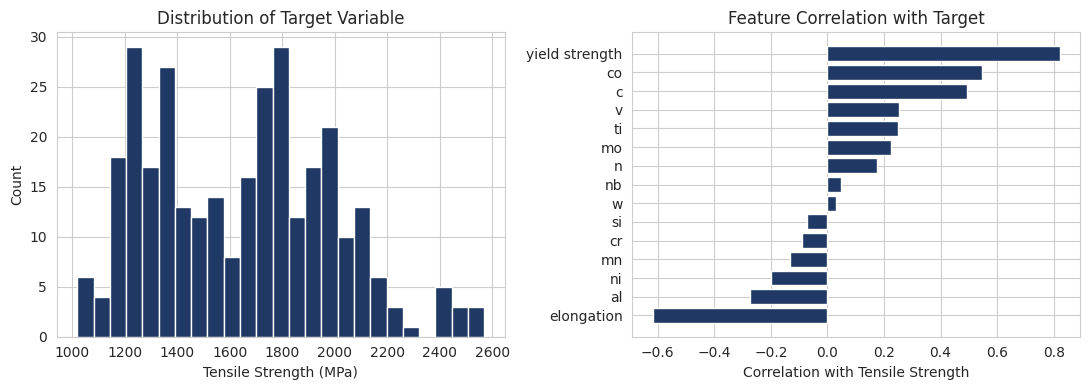

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(df["tensile strength"], bins=25, color="#1F3864", edgecolor="white")
ax[0].set_xlabel("Tensile Strength (MPa)")
ax[0].set_ylabel("Count")
ax[0].set_title("Distribution of Target Variable")

corr_with_target = df.drop(columns=["formula"]).corr()["tensile strength"].drop("tensile strength").sort_values()
ax[1].barh(corr_with_target.index, corr_with_target.values, color="#1F3864")
ax[1].set_xlabel("Correlation with Tensile Strength")
ax[1].set_title("Feature Correlation with Target")
plt.tight_layout()
plt.savefig("fig_eda.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Preprocessing 📌

The alloying-element columns are already numeric fractions with no missing values, so minimal cleaning is needed here. We drop the `formula` (text) and `yield strength`/`elongation` columns (not our target) to isolate the feature matrix.

**Your group:** this is where you'd handle missing values, encode categorical variables, or engineer new features if your dataset needs it.


In [5]:
feature_cols = ["c","mn","si","cr","ni","mo","v","n","nb","co","w","al","ti"]
X = df[feature_cols]
y = df["tensile strength"]

print(f"Features: {X.shape[1]} columns, {X.shape[0]} rows")
print(f"Target range: {y.min():.1f} to {y.max():.1f} MPa")


Features: 13 columns, 312 rows
Target range: 1019.0 to 2570.0 MPa


## 6. Train/Test Split 📌

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")


Train: 249 rows | Test: 63 rows


## 7. Model Training 🔧

**Example (this notebook):** Random Forest Regressor, 200 trees, default depth. Random Forest is a good default for tabular materials data — it handles nonlinear relationships and gives feature importances for free.

**Your group:** this is where your technique choice goes — Linear Regression, Logistic Regression, K-Means, etc., matched to your problem statement in Section 1.


In [7]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
print("Model trained.")


Model trained.


## 8. Evaluation 📌

Report the metrics appropriate to your technique. For regression: R², RMSE, MAE. For classification: accuracy, precision/recall, confusion matrix. For clustering: silhouette score, cluster sizes.


In [8]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R²   : {r2:.3f}")
print(f"RMSE : {rmse:.1f} MPa")
print(f"MAE  : {mae:.1f} MPa")


R²   : 0.889
RMSE : 106.1 MPa
MAE  : 70.3 MPa


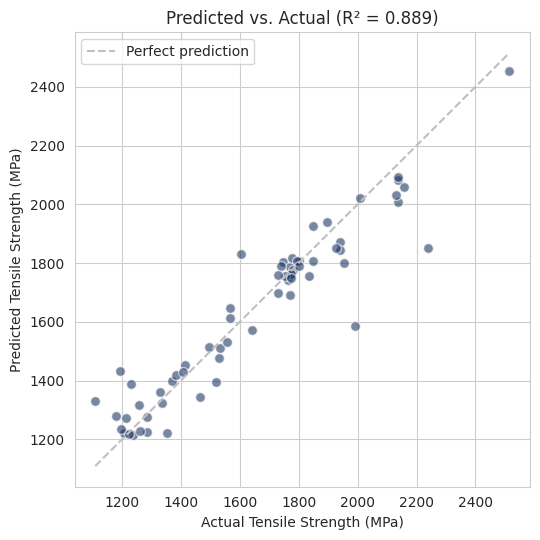

In [9]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_test, y_pred, alpha=0.6, color="#1F3864", edgecolor="white", s=50)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "--", color="#BFBFBF", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual Tensile Strength (MPa)")
ax.set_ylabel("Predicted Tensile Strength (MPa)")
ax.set_title(f"Predicted vs. Actual (R² = {r2:.3f})")
ax.legend()
plt.tight_layout()
plt.savefig("fig_predictions.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Feature Importance 📌

Which inputs mattered most to the model? This is often the most useful output for a materials scientist — it turns a black-box model into a design insight.


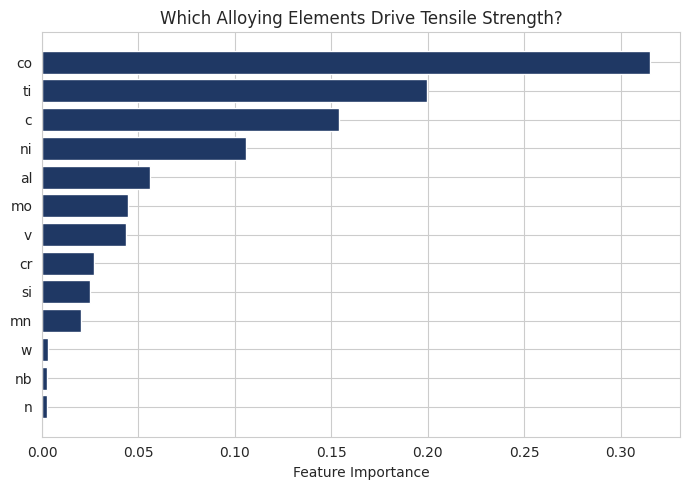

Top 3 most important elements:
co    0.315
ti    0.200
c     0.154
dtype: float64


In [10]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(importances.index, importances.values, color="#1F3864")
ax.set_xlabel("Feature Importance")
ax.set_title("Which Alloying Elements Drive Tensile Strength?")
plt.tight_layout()
plt.savefig("fig_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 3 most important elements:")
print(importances.sort_values(ascending=False).head(3).round(3))


## 10. Conclusions & Limitations 🔧

**Example (this notebook):**
- The model explains a substantial share of the variance in tensile strength from composition alone (see R² above).
- Co, Ti, and C emerge as the most influential alloying elements in this dataset (R² = 0.889 on held-out test data) — consistent with their known strengthening roles (cobalt solid-solution/precipitation strengthening, titanium carbide formation, and carbon's classical role in steel hardening).
- **Limitation:** 312 samples is a modest dataset for 13 features; the model may not generalize well outside the composition ranges present here. It also doesn't account for processing history (heat treatment, cold work), which strongly affects real tensile strength.

**Your group:** replace with your own findings. Always include at least one honest limitation — it's expected, not a weakness.


## 11. Individual Contributions 🔧

*(For your group's final submission — one line per member, matching the Report template.)*

| Member | Contribution |
|---|---|
| *Name 1* | *e.g., data sourcing & cleaning* |
| *Name 2* | *e.g., model building & tuning* |
| *Name 3* | *e.g., report writing* |
